# Experiment 3 — Does factorial sparsity recover primitive features?

This notebook tests one hypothesis only:

> As named factorial features become rarer, does the default L1 SAE in SAELens
> recover the known primitive directions more accurately?

The only experimental variable is `N`, the number of features in each of two
factor sets. Everything else is fixed.

For every sample, exactly one `x` feature and one `y` feature are active:

\[
P(x_i)=P(y_j)=\frac{1}{N}, \qquad
P(x_i,y_j)=\frac{1}{N^2}.
\]

**Important:** the ground-truth per-example L0 remains 2. Increasing sparsity
here means that each named primitive occurs less frequently across the dataset
as `N` grows.

## Experimental sequence

1. Load and verify the trained `N=2` antipodal toy-model geometry.
2. Verify that `SparseFactorialGenerator` exactly reproduces its hidden states.
3. Measure primitive recovery for a default SAE at `N=2`.
4. Train the same SAE setup at `N = 2, 4, 8, ..., 256`.
5. Measure recovery using exactly four aggregate metrics:
   - one-to-one Hungarian recovery at cosine cutoffs 0.70, 0.80, and 0.90;
   - Mean Max Cosine Similarity (MMCS).

Completed SAEs are checkpointed. The full experiment uses 250M generated
training activations per `N`.

In [1]:
from __future__ import annotations

import json
import sys
from collections.abc import Iterator, Sequence
from dataclasses import asdict, dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn.functional as F
from scipy.optimize import linear_sum_assignment


WORKING_DIR = Path.cwd().resolve()
if (WORKING_DIR / 'toy_model.py').exists():
    EXPERIMENT_DIR = WORKING_DIR
elif (WORKING_DIR / 'composed-features' / 'toy_model.py').exists():
    EXPERIMENT_DIR = WORKING_DIR / 'composed-features'
else:
    raise FileNotFoundError(
        'Run from the repository root or composed-features directory.'
    )

if str(EXPERIMENT_DIR) not in sys.path:
    sys.path.insert(0, str(EXPERIMENT_DIR))

from sae_lens import StandardTrainingSAE, StandardTrainingSAEConfig
from sae_lens.config import LoggingConfig, SAETrainerConfig
from sae_lens.training.sae_trainer import SAETrainer

from sparse_factorial_generator import FactorialConfig, SparseFactorialGenerator
from toy_model import (
    FULL_TOY_TRAINING,
    default_device,
    load_toy_model,
    make_correlated_amplitude_model,
)


DEVICE = default_device()
ARTIFACT_ROOT = EXPERIMENT_DIR / 'artifacts' / '03_sparse_factorial_antipodal'
SAE_CHECKPOINT_ROOT = ARTIFACT_ROOT / 'sae_checkpoints'
RESULTS_ROOT = ARTIFACT_ROOT / 'results'
for path in (SAE_CHECKPOINT_ROOT, RESULTS_ROOT):
    path.mkdir(parents=True, exist_ok=True)

print('Experiment directory:', EXPERIMENT_DIR)
print('Device:', DEVICE)
print('Artifact root:', ARTIFACT_ROOT)

Experiment directory: /Users/abdulhakeemadefioye/Desktop/SAE/composed-features
Device: mps
Artifact root: /Users/abdulhakeemadefioye/Desktop/SAE/composed-features/artifacts/03_sparse_factorial_antipodal


In [2]:
# Quick mode checks the pipeline with a small activation budget. Full mode uses
# 250M freshly generated activations for every SAE.
QUICK_MODE = False

FULL_TRAINING_SAMPLES = 250_000_000
QUICK_TRAINING_SAMPLES = 262_144
TRAINING_SAMPLES = (
    QUICK_TRAINING_SAMPLES if QUICK_MODE else FULL_TRAINING_SAMPLES
)
TRAIN_BATCH_SIZE = 1_024

# Fixed default StandardTrainingSAE configuration.
LEARNING_RATE = 3e-4
L1_COEFFICIENT = 0.3
ADAM_BETA1 = 0.0
ADAM_BETA2 = 0.999

N_VALUES = (2, 4, 8, 16, 32, 64, 128, 256)
SAE_SEED = 0
DICTIONARY_SEED = 0

RUN_N2_REPLICATION = False
RUN_N_SWEEP = False

HUNGARIAN_THRESHOLDS = (0.70, 0.80, 0.90)
RECOVERY_METRICS = [
    'hungarian_recovery_fraction_70',
    'hungarian_recovery_fraction_80',
    'hungarian_recovery_fraction_90',
    'mean_max_primitive_cosine',
]

print(f'Quick mode: {QUICK_MODE}')
print(f'Training samples per SAE: {TRAINING_SAMPLES:,}')
print(f'Fixed SAE seed: {SAE_SEED}')
print(f'N-sweep runs: {len(N_VALUES)}')

Quick mode: False
Training samples per SAE: 250,000,000
Fixed SAE seed: 0
N-sweep runs: 8


## 1. Verify the trained `N=2` antipodal geometry

The saved four-feature toy model supplies the exact base geometry. Its two `x`
directions must be antipodal, its two `y` directions must be antipodal, and the
`x` and `y` axes must be orthogonal.

In [3]:
toy_checkpoint = EXPERIMENT_DIR / 'artifacts' / 'toy_model_full.pt'
if not toy_checkpoint.exists():
    raise FileNotFoundError(
        f'Missing {toy_checkpoint}. Run 01_correlated_feature_amplitudes.ipynb first.'
    )

trained_toy_model = make_correlated_amplitude_model(
    FULL_TOY_TRAINING, device=DEVICE
)
load_toy_model(trained_toy_model, toy_checkpoint)
trained_toy_model.eval()

TRAINED_DICTIONARY = trained_toy_model.W.detach().clone()
trained_unit = F.normalize(TRAINED_DICTIONARY, dim=1)
trained_gram = trained_unit @ trained_unit.T

print('Trained dictionary:')
print(TRAINED_DICTIONARY.cpu())
print('\nCosine Gram matrix:')
print(trained_gram.cpu())

assert torch.allclose(
    trained_gram[0, 1], torch.tensor(-1.0, device=DEVICE), atol=2e-4
)
assert torch.allclose(
    trained_gram[2, 3], torch.tensor(-1.0, device=DEVICE), atol=2e-4
)
assert trained_gram[:2, 2:].abs().max() < 2e-4
print('\nVerified: two orthogonal antipodal axes.')

Trained dictionary:
tensor([[ 0.9061,  0.4231],
        [-0.9061, -0.4231],
        [ 0.4231, -0.9061],
        [-0.4231,  0.9061]])

Cosine Gram matrix:
tensor([[ 1.0000e+00, -1.0000e+00, -3.0918e-07, -7.8480e-06],
        [-1.0000e+00,  1.0000e+00,  9.9812e-06, -1.8241e-06],
        [-3.0918e-07,  9.9812e-06,  1.0000e+00, -1.0000e+00],
        [-7.8480e-06, -1.8241e-06, -1.0000e+00,  1.0000e+00]])

Verified: two orthogonal antipodal axes.


## 2. Verify exact generator equivalence at `N=2`

With the trained dictionary, identical pair amplitudes, and the same sparse
coefficient vector `z`, the generator output must equal the trained toy model's
hidden state:

\[
h_{generator}=zW=h_{toy\ model}.
\]

In [4]:
equivalence_generator = SparseFactorialGenerator(
    FactorialConfig(
        n_x=2,
        n_y=2,
        activation_dim=2,
        amplitude_correlation=1.0,
        singleton_probability=0.0,
        seed=123,
    ),
    device=str(DEVICE),
    true_dictionary=TRAINED_DICTIONARY,
    normalize_dictionary=False,
)

h_generator, z_equivalence = equivalence_generator.sample(8_192)
with torch.no_grad():
    trained_toy_model(z_equivalence)
    h_model = trained_toy_model.h.detach().clone()

max_error = float((h_generator - h_model).abs().max())
assert max_error < 1e-6
assert torch.allclose(
    z_equivalence[:, :2].sum(dim=1),
    z_equivalence[:, 2:].sum(dim=1),
)
assert torch.all((z_equivalence[:, :2] > 0).sum(dim=1) == 1)
assert torch.all((z_equivalence[:, 2:] > 0).sum(dim=1) == 1)

print('Maximum hidden-activation error:', max_error)
print('Exact N=2 equivalence passed.')

Maximum hidden-activation error: 0.0
Exact N=2 equivalence passed.


## 3. Extend the same geometry to larger `N`

For even `N`, each factor set contains `N/2` antipodal axis pairs. The `x` axes
and `y` axes occupy orthogonal subspaces, and a random orthogonal rotation removes
coordinate-axis artifacts without changing any angles.

There are `2N` primitive directions in `N` activation dimensions. At `N=2`,
dictionary seed 0 returns the exact trained dictionary.

In [5]:
def _orthogonal_matrix(dim: int, seed: int) -> torch.Tensor:
    generator = torch.Generator(device='cpu').manual_seed(seed)
    matrix = torch.randn(dim, dim, generator=generator)
    q, r = torch.linalg.qr(matrix)
    signs = torch.where(torch.diag(r) >= 0, 1.0, -1.0)
    return q * signs.unsqueeze(0)


def make_antipodal_dictionary(
    n_per_set: int,
    *,
    seed: int = 0,
    device: torch.device | str = 'cpu',
) -> torch.Tensor:
    if n_per_set <= 0 or n_per_set % 2:
        raise ValueError('Antipodal geometry requires a positive, even N.')

    if n_per_set == 2 and seed == 0:
        return TRAINED_DICTIONARY.detach().to(device).clone()

    half = n_per_set // 2
    dictionary = torch.zeros(2 * n_per_set, n_per_set)
    for axis in range(half):
        dictionary[2 * axis, axis] = 1.0
        dictionary[2 * axis + 1, axis] = -1.0

        y_offset = n_per_set
        y_axis = half + axis
        dictionary[y_offset + 2 * axis, y_axis] = 1.0
        dictionary[y_offset + 2 * axis + 1, y_axis] = -1.0

    return (dictionary @ _orthogonal_matrix(n_per_set, seed)).to(device)


def verify_antipodal_dictionary(dictionary: torch.Tensor, n_per_set: int):
    unit = F.normalize(dictionary, dim=1)
    x_group = unit[:n_per_set]
    y_group = unit[n_per_set:]
    cross_group_max = float((x_group @ y_group.T).abs().max())

    for group in (x_group, y_group):
        for index in range(0, n_per_set, 2):
            assert torch.allclose(
                group[index], -group[index + 1], atol=2e-4
            )
    assert cross_group_max < 2e-4
    return {'cross_group_max_abs_cosine': cross_group_max}


for demo_n in (2, 8, 32):
    demo_dictionary = make_antipodal_dictionary(demo_n, device=DEVICE)
    print(f'N={demo_n}:', verify_antipodal_dictionary(demo_dictionary, demo_n))

N=2: {'cross_group_max_abs_cosine': 9.98122868622886e-06}
N=8: {'cross_group_max_abs_cosine': 1.1175870895385742e-07}
N=32: {'cross_group_max_abs_cosine': 1.3585741953647812e-07}


## 4. Fixed SAE setup

Only `N` changes. Every training run uses:

- perfectly correlated pair amplitudes (`C=1`);
- no singleton samples;
- activation dimension `N`;
- exactly `2N` SAE latents, one slot per primitive;
- SAELens `StandardTrainingSAE` with the same L1 coefficient and optimizer;
- fresh generated activations and resumable final-model checkpoints.

In [6]:
def _slug_value(value) -> str:
    return str(value).replace('-', 'm').replace('.', 'p')


@dataclass(frozen=True)
class ExperimentSpec:
    study: str
    n_per_set: int
    dictionary_seed: int = 0
    data_seed: int = 0
    sae_seed: int = 0
    training_samples: int = TRAINING_SAMPLES
    batch_size: int = TRAIN_BATCH_SIZE
    lr: float = LEARNING_RATE
    l1_coefficient: float = L1_COEFFICIENT

    @property
    def activation_dim(self) -> int:
        return self.n_per_set

    @property
    def d_sae(self) -> int:
        return 2 * self.n_per_set

    def checkpoint_slug(self) -> str:
        # This matches the earlier notebook's primary antipodal checkpoint names,
        # allowing completed runs to be reused.
        fields = (
            f'N{self.n_per_set:04d}',
            'g-antipodal',
            'C-1p0',
            's-0p0',
            'w-1p0',
            f'dict-{self.dictionary_seed}',
            f'data-{self.data_seed}',
            f'sae-{self.sae_seed}',
            'norm-0',
            f'T-{self.training_samples}',
            f'lr-{_slug_value(self.lr)}',
            f'l1-{_slug_value(self.l1_coefficient)}',
        )
        return '__'.join(fields)


def build_dictionary(spec: ExperimentSpec) -> torch.Tensor:
    return make_antipodal_dictionary(
        spec.n_per_set, seed=spec.dictionary_seed, device=DEVICE
    )


def build_generator(
    spec: ExperimentSpec,
    *,
    data_seed: int | None = None,
) -> SparseFactorialGenerator:
    return SparseFactorialGenerator(
        FactorialConfig(
            n_x=spec.n_per_set,
            n_y=spec.n_per_set,
            activation_dim=spec.activation_dim,
            amplitude_correlation=1.0,
            singleton_probability=0.0,
            noise_std=0.0,
            seed=spec.data_seed if data_seed is None else data_seed,
        ),
        device=str(DEVICE),
        true_dictionary=build_dictionary(spec),
        normalize_dictionary=False,
    )


class SparseFactorialActivationIterator(Iterator[torch.Tensor]):
    def __init__(self, generator: SparseFactorialGenerator, batch_size: int):
        self.generator = generator
        self.batch_size = batch_size

    def __iter__(self):
        return self

    @torch.no_grad()
    def __next__(self) -> torch.Tensor:
        hidden, _ = self.generator.sample(self.batch_size)
        return hidden.detach()


def make_standard_sae(spec: ExperimentSpec) -> StandardTrainingSAE:
    torch.manual_seed(spec.sae_seed)
    sae_cfg = StandardTrainingSAEConfig(
        d_in=spec.activation_dim,
        d_sae=spec.d_sae,
        device=str(DEVICE),
        dtype='float32',
        apply_b_dec_to_input=False,
        normalize_activations='none',
        l1_coefficient=spec.l1_coefficient,
        lp_norm=1.0,
        l1_warm_up_steps=0,
        decoder_init_norm=1.0,
    )
    return StandardTrainingSAE(sae_cfg).to(DEVICE)


def make_trainer(
    spec: ExperimentSpec,
    sae: StandardTrainingSAE,
    generator: SparseFactorialGenerator,
) -> SAETrainer:
    trainer_cfg = SAETrainerConfig(
        total_training_samples=spec.training_samples,
        train_batch_size_samples=spec.batch_size,
        lr=spec.lr,
        lr_end=spec.lr,
        lr_scheduler_name='constant',
        lr_warm_up_steps=0,
        lr_decay_steps=0,
        adam_beta1=ADAM_BETA1,
        adam_beta2=ADAM_BETA2,
        device=str(DEVICE),
        n_checkpoints=0,
        checkpoint_path=None,
        save_final_checkpoint=False,
        logger=LoggingConfig(
            log_to_wandb=False,
            eval_every_n_wandb_logs=2**31 - 1,
        ),
        n_batches_for_norm_estimate=1,
    )
    return SAETrainer(
        cfg=trainer_cfg,
        sae=sae,
        data_provider=SparseFactorialActivationIterator(generator, spec.batch_size),
    )


def train_or_load_sae(spec: ExperimentSpec) -> StandardTrainingSAE:
    run_dir = SAE_CHECKPOINT_ROOT / spec.checkpoint_slug()
    config_path = run_dir / 'cfg.json'
    weights_path = run_dir / 'sae_weights.safetensors'

    if config_path.exists() and weights_path.exists():
        sae = StandardTrainingSAE.load_from_disk(
            run_dir, device=str(DEVICE), dtype='float32'
        )
        print('Loaded', run_dir.name)
        return sae.to(DEVICE)

    generator = build_generator(spec)
    sae = make_standard_sae(spec)
    sae = make_trainer(spec, sae, generator).fit()
    run_dir.mkdir(parents=True, exist_ok=True)
    sae.save_model(run_dir)
    (run_dir / 'experiment_spec.json').write_text(
        json.dumps(asdict(spec), indent=2) + '\n'
    )
    print('Saved', run_dir.name)
    return sae

## 5. The four primitive-recovery metrics

All composition metrics have been removed. The evaluation uses only the known
primitive directions and the learned SAE decoder directions.

Let

\[
S_{ik}=\cos(D_i,f_k)
\]

be the cosine-similarity matrix between the `2N` true primitives `D_i` and the
`2N` learned decoder directions `f_k`.

### One-to-one Hungarian recovery

Hungarian matching finds the globally optimal one-to-one assignment between
true primitives and learned decoders. For each cutoff, the metric is the
fraction of assigned pairs whose cosine meets the cutoff:

- `hungarian_recovery_fraction_70`;
- `hungarian_recovery_fraction_80`;
- `hungarian_recovery_fraction_90`.

The 0.70 cutoff is permissive: an ideal equal-weight composed direction has
cosine `1/sqrt(2) ~= 0.707` with either constituent primitive. Therefore the
0.80 and especially 0.90 curves are stronger evidence of genuine primitive
alignment.

### Mean Max Cosine Similarity (MMCS)

For every true primitive, find its most similar learned decoder and average:

\[
\operatorname{MMCS}
=\frac{1}{2N}\sum_{i=1}^{2N}\max_k S_{ik}.
\]

This is true-primitive-to-nearest-decoder matching. It does not enforce a
one-to-one assignment, which is why it is reported alongside Hungarian
matching.

In [7]:
@torch.no_grad()
def primitive_recovery_metrics(
    sae: StandardTrainingSAE,
    dictionary: torch.Tensor,
) -> dict[str, float]:
    decoder = F.normalize(sae.W_dec.detach().float(), dim=1)
    primitives = F.normalize(dictionary.detach().float(), dim=1)
    similarity = primitives @ decoder.T

    # Non-bijective coverage: for every true primitive, retain its nearest
    # learned decoder, then average across true primitives.
    mean_max_primitive_cosine = float(
        similarity.max(dim=1).values.mean()
    )

    # Bijective coverage: globally optimal one-to-one primitive/decoder match.
    primitive_rows, decoder_cols = linear_sum_assignment(
        -similarity.detach().cpu().numpy()
    )
    assigned = similarity[
        torch.as_tensor(primitive_rows, device=similarity.device),
        torch.as_tensor(decoder_cols, device=similarity.device),
    ]

    return {
        'hungarian_recovery_fraction_70': float(
            (assigned >= HUNGARIAN_THRESHOLDS[0]).float().mean()
        ),
        'hungarian_recovery_fraction_80': float(
            (assigned >= HUNGARIAN_THRESHOLDS[1]).float().mean()
        ),
        'hungarian_recovery_fraction_90': float(
            (assigned >= HUNGARIAN_THRESHOLDS[2]).float().mean()
        ),
        'mean_max_primitive_cosine': mean_max_primitive_cosine,
    }


def analyze_run(spec: ExperimentSpec, sae: StandardTrainingSAE) -> dict:
    return {
        'n_per_set': spec.n_per_set,
        **primitive_recovery_metrics(sae, build_dictionary(spec)),
    }


def run_specs(
    specs: Sequence[ExperimentSpec],
    *,
    summary_path: Path,
) -> pd.DataFrame:
    unique_specs = {spec.checkpoint_slug(): spec for spec in specs}
    summaries = []

    for index, spec in enumerate(unique_specs.values(), start=1):
        print(f'[{index}/{len(unique_specs)}] N={spec.n_per_set}')
        sae = train_or_load_sae(spec)
        summaries.append(analyze_run(spec, sae))
        pd.DataFrame(summaries).to_csv(summary_path, index=False)
        del sae
        if DEVICE.type == 'mps':
            torch.mps.empty_cache()
        elif DEVICE.type == 'cuda':
            torch.cuda.empty_cache()

    return pd.DataFrame(summaries)


def load_results(summary_path: Path) -> pd.DataFrame | None:
    if not summary_path.exists():
        return None
    frame = pd.read_csv(summary_path)
    required = {'n_per_set', *RECOVERY_METRICS}
    if not required.issubset(frame.columns):
        print('Ignoring obsolete results file:', summary_path)
        return None
    return frame.sort_values('n_per_set').reset_index(drop=True)

## 6. `N=2` baseline

This baseline applies the same four primitive-recovery metrics to the original
trained antipodal geometry. It establishes the low-`N` starting point before
the sparsity sweep.

In [8]:
# Set these flags deliberately before running the training cells.
RUN_N2_REPLICATION = False
QUICK_MODE, RUN_N2_REPLICATION

(False, False)

In [9]:
n2_spec = ExperimentSpec(
    study='n2_replication',
    n_per_set=2,
    dictionary_seed=DICTIONARY_SEED,
    data_seed=DICTIONARY_SEED,
    sae_seed=SAE_SEED,
)

n2_suffix = 'quick' if QUICK_MODE else 'full_250m'
n2_summary_path = RESULTS_ROOT / f'n2_primitive_recovery_{n2_suffix}.csv'

if RUN_N2_REPLICATION:
    n2_results = run_specs([n2_spec], summary_path=n2_summary_path)
else:
    n2_results = load_results(n2_summary_path)
    print('Set RUN_N2_REPLICATION=True to run the N=2 baseline.')

if n2_results is not None:
    display(n2_results[['n_per_set', *RECOVERY_METRICS]])

Set RUN_N2_REPLICATION=True to run the N=2 baseline.


,n_per_set,hungarian_recovery_fraction_70,hungarian_recovery_fraction_80,hungarian_recovery_fraction_90,mean_max_primitive_cosine
0,2,1.0,0.0,0.0,0.70718


## 7. Main `N` sparsity sweep

The only changing quantity is `N`. Primitive frequency falls as `1/N`, while
all training settings and the representation ratio remain fixed.

Evidence for improved primitive recovery is an upward trend with `N` in all
four metrics. The 0.80 and 0.90 Hungarian curves are the stricter recovery
criteria; MMCS supplies the complementary non-bijective view.

In [10]:
RUN_N_SWEEP = False

Set RUN_N_SWEEP=True to run the sparsity sweep.


,n_per_set,hungarian_recovery_fraction_70,hungarian_recovery_fraction_80,hungarian_recovery_fraction_90,mean_max_primitive_cosine
0,2,1.000000,0.000000,0.000000,0.707180
1,4,0.500000,0.000000,0.000000,0.707105
2,8,1.000000,1.000000,1.000000,0.999992
3,16,0.968750,0.937500,0.937500,0.980191
4,32,0.984375,0.968750,0.968750,0.990193
5,64,0.960938,0.953125,0.953125,0.965376
6,128,0.925781,0.925781,0.925781,0.930293
7,256,0.892578,0.890625,0.890625,0.897241


Saved /Users/abdulhakeemadefioye/Desktop/SAE/composed-features/artifacts/03_sparse_factorial_antipodal/results/hungarian_recovery_fraction_70_by_n_full_250m.png
Saved /Users/abdulhakeemadefioye/Desktop/SAE/composed-features/artifacts/03_sparse_factorial_antipodal/results/hungarian_recovery_fraction_80_by_n_full_250m.png
Saved /Users/abdulhakeemadefioye/Desktop/SAE/composed-features/artifacts/03_sparse_factorial_antipodal/results/hungarian_recovery_fraction_90_by_n_full_250m.png
Saved /Users/abdulhakeemadefioye/Desktop/SAE/composed-features/artifacts/03_sparse_factorial_antipodal/results/mean_max_primitive_cosine_by_n_full_250m.png


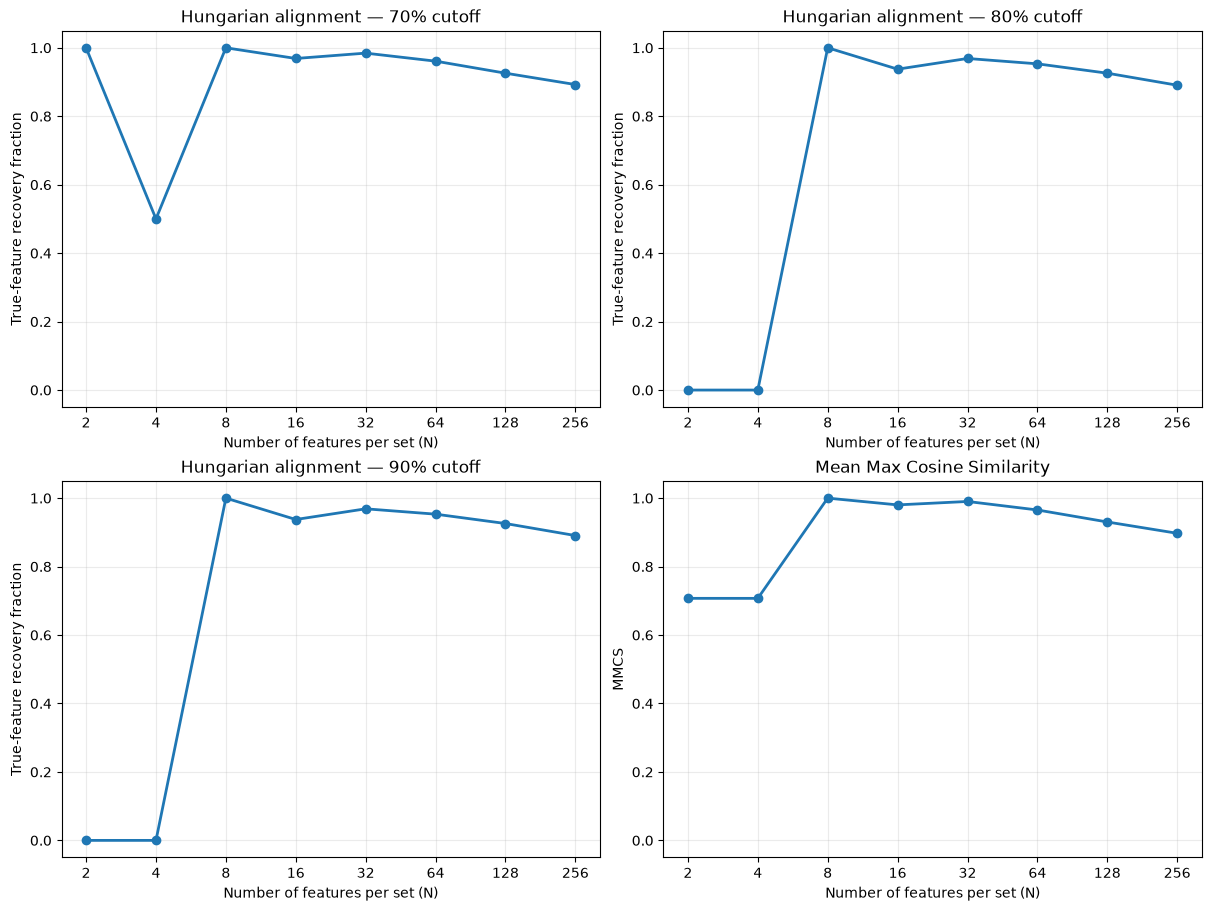

In [11]:
sweep_specs = [
    ExperimentSpec(
        study='n_sparsity_sweep',
        n_per_set=n_per_set,
        dictionary_seed=DICTIONARY_SEED,
        data_seed=DICTIONARY_SEED,
        sae_seed=SAE_SEED,
    )
    for n_per_set in N_VALUES
]

sweep_suffix = 'quick' if QUICK_MODE else 'full_250m'
sweep_summary_path = RESULTS_ROOT / f'n_primitive_recovery_{sweep_suffix}.csv'

if RUN_N_SWEEP:
    sweep_results = run_specs(
        sweep_specs, summary_path=sweep_summary_path
    )
else:
    sweep_results = load_results(sweep_summary_path)
    print('Set RUN_N_SWEEP=True to run the sparsity sweep.')


PLOT_SPECS = [
    (
        'hungarian_recovery_fraction_70',
        'Hungarian alignment — 70% cutoff',
        'True-feature recovery fraction',
    ),
    (
        'hungarian_recovery_fraction_80',
        'Hungarian alignment — 80% cutoff',
        'True-feature recovery fraction',
    ),
    (
        'hungarian_recovery_fraction_90',
        'Hungarian alignment — 90% cutoff',
        'True-feature recovery fraction',
    ),
    (
        'mean_max_primitive_cosine',
        'Mean Max Cosine Similarity',
        'MMCS',
    ),
]


def plot_metric(
    ax, frame: pd.DataFrame, metric: str, title: str, ylabel: str
):
    ordered = frame.sort_values('n_per_set')
    ax.plot(ordered['n_per_set'], ordered[metric], marker='o', linewidth=2)
    ax.set(
        title=title,
        xlabel='Number of features per set (N)',
        ylabel=ylabel,
        xscale='log',
        ylim=(-0.05, 1.05),
    )
    ax.set_xscale('log', base=2)
    ax.set_xticks(ordered['n_per_set'])
    ax.set_xticklabels([str(int(n)) for n in ordered['n_per_set']])
    ax.get_xaxis().set_minor_formatter(plt.NullFormatter())
    ax.grid(alpha=0.25)


def save_individual_metric_plots(frame: pd.DataFrame):
    saved_paths = []
    for metric, title, ylabel in PLOT_SPECS:
        figure, axis = plt.subplots(figsize=(6, 4))
        plot_metric(axis, frame, metric, title, ylabel)
        figure.tight_layout()
        path = RESULTS_ROOT / f'{metric}_by_n_{sweep_suffix}.png'
        figure.savefig(path, dpi=200, bbox_inches='tight')
        plt.close(figure)
        saved_paths.append(path)
    return saved_paths


def display_metric_grid(frame: pd.DataFrame):
    figure, axes = plt.subplots(
        2, 2, figsize=(12, 9), constrained_layout=True
    )
    for axis, (metric, title, ylabel) in zip(
        axes.flat, PLOT_SPECS, strict=True
    ):
        plot_metric(axis, frame, metric, title, ylabel)
    return figure, axes


if sweep_results is not None:
    display(
        sweep_results[['n_per_set', *RECOVERY_METRICS]]
        .sort_values('n_per_set')
        .reset_index(drop=True)
    )
    saved_plot_paths = save_individual_metric_plots(sweep_results)
    for path in saved_plot_paths:
        print('Saved', path)
    metric_grid, axes = display_metric_grid(sweep_results)
    plt.show()

## Replot MMCS and Hungarian 90% from the saved CSV

This cell reads the completed 250M-run summary and does not train or load an SAE.

Saved /Users/abdulhakeemadefioye/Desktop/SAE/composed-features/artifacts/03_sparse_factorial_antipodal/results/hungarian_alignment_90_by_n_from_saved_csv.png
Saved /Users/abdulhakeemadefioye/Desktop/SAE/composed-features/artifacts/03_sparse_factorial_antipodal/results/mmcs_by_n_from_saved_csv.png


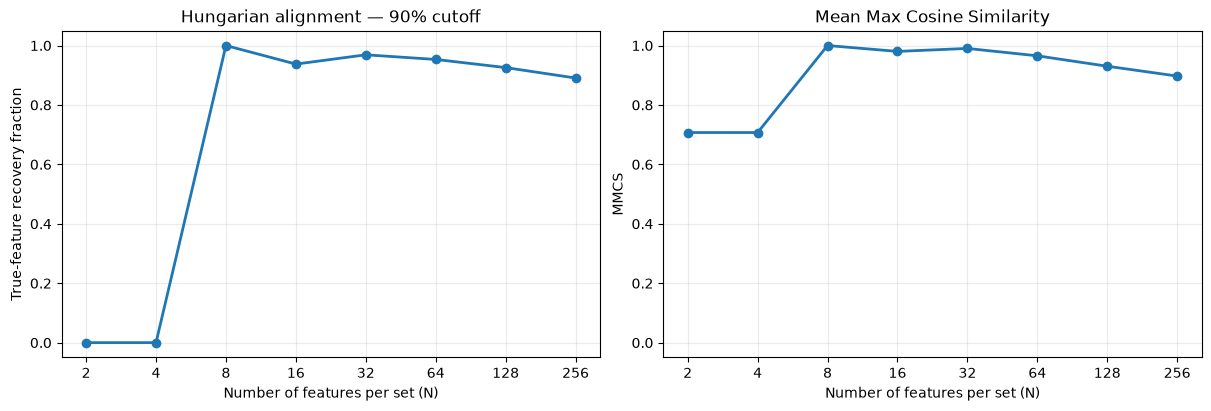

In [12]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


working_directory = Path.cwd().resolve()
if (working_directory / 'composed-features').is_dir():
    experiment_directory = working_directory / 'composed-features'
elif working_directory.name == 'composed-features':
    experiment_directory = working_directory
else:
    raise RuntimeError(
        'Run this cell from the repository root or composed-features directory.'
    )

saved_results_directory = (
    experiment_directory
    / 'artifacts'
    / '03_sparse_factorial_antipodal'
    / 'results'
)
saved_summary_path = (
    saved_results_directory / 'n_primitive_recovery_full_250m.csv'
)
if not saved_summary_path.exists():
    raise FileNotFoundError(f'Saved summary not found: {saved_summary_path}')

saved_results = pd.read_csv(saved_summary_path)

SAVED_PLOT_SPECS = [
    (
        'hungarian_recovery_fraction_90',
        'Hungarian alignment — 90% cutoff',
        'True-feature recovery fraction',
        'hungarian_alignment_90_by_n_from_saved_csv.png',
    ),
    (
        'mean_max_primitive_cosine',
        'Mean Max Cosine Similarity',
        'MMCS',
        'mmcs_by_n_from_saved_csv.png',
    ),
]

required_columns = {'n_per_set'} | {
    metric for metric, _, _, _ in SAVED_PLOT_SPECS
}
missing_columns = required_columns.difference(saved_results.columns)
if missing_columns:
    raise ValueError(
        f'{saved_summary_path} is missing columns: {sorted(missing_columns)}'
    )


def plot_saved_metric(ax, frame, metric, title, ylabel):
    ordered = frame.sort_values('n_per_set')
    ax.plot(
        ordered['n_per_set'], ordered[metric], marker='o', linewidth=2
    )
    ax.set(
        title=title,
        xlabel='Number of features per set (N)',
        ylabel=ylabel,
        ylim=(-0.05, 1.05),
    )
    ax.set_xscale('log', base=2)
    ax.set_xticks(ordered['n_per_set'])
    ax.set_xticklabels([str(int(n)) for n in ordered['n_per_set']])
    ax.get_xaxis().set_minor_formatter(plt.NullFormatter())
    ax.grid(alpha=0.25)


figure, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
for axis, (metric, title, ylabel, filename) in zip(
    axes, SAVED_PLOT_SPECS, strict=True
):
    plot_saved_metric(axis, saved_results, metric, title, ylabel)

    individual_figure, individual_axis = plt.subplots(figsize=(6, 4))
    plot_saved_metric(
        individual_axis, saved_results, metric, title, ylabel
    )
    individual_figure.tight_layout()
    output_path = saved_results_directory / filename
    individual_figure.savefig(output_path, dpi=200, bbox_inches='tight')
    plt.close(individual_figure)
    print('Saved', output_path)

plt.show()

## 8. 128M `N` sweep across five SAE seeds

This robustness run uses the same `N = 2, 4, ..., 256` sweep with 128M
training samples per SAE and SAE seeds 0 through 4. The antipodal dictionary
and generated-data stream remain fixed at seed 0, so variation across runs
measures SAE initialization/training variability rather than variation in the
ground-truth features or training data.

For Hungarian recovery at the 0.90 cosine cutoff and MMCS, the plots and
aggregate CSV report the mean and two-sided 95% Student-t confidence interval
across the five SAE seeds. The code saves progress after every completed SAE
and reuses both saved result rows and SAE checkpoints when rerun.

,n_per_set,n_sae_seeds,hungarian_90_mean,hungarian_90_ci95_lower,hungarian_90_ci95_upper,mmcs_mean,mmcs_ci95_lower,mmcs_ci95_upper
0,2,5,0.0000,0.0000,0.0000,0.7320,0.7047,0.7592
1,4,5,0.3000,-0.2553,0.8553,0.7541,0.5231,0.9850
2,8,5,0.9625,0.8584,1.0666,0.9916,0.9684,1.0149
3,16,5,0.9750,0.9325,1.0175,0.9921,0.9786,1.0055
4,32,5,0.9719,0.9431,1.0007,0.9846,0.9706,0.9986
5,64,5,0.9500,0.9389,0.9611,0.9656,0.9562,0.9750
6,128,5,0.9344,0.9209,0.9478,0.9407,0.9285,0.9528
7,256,5,0.8895,0.8825,0.8964,0.8947,0.8890,0.9003


Saved /Users/abdulhakeemadefioye/Desktop/SAE/composed-features/artifacts/03_sparse_factorial_antipodal/results/n_primitive_recovery_128m_5_sae_seeds_per_seed.csv
Saved /Users/abdulhakeemadefioye/Desktop/SAE/composed-features/artifacts/03_sparse_factorial_antipodal/results/n_primitive_recovery_128m_5_sae_seeds_aggregate.csv
Saved /Users/abdulhakeemadefioye/Desktop/SAE/composed-features/artifacts/03_sparse_factorial_antipodal/results/hungarian_alignment_90_by_n_128m_5_sae_seeds.png
Saved /Users/abdulhakeemadefioye/Desktop/SAE/composed-features/artifacts/03_sparse_factorial_antipodal/results/mmcs_by_n_128m_5_sae_seeds.png
Saved /Users/abdulhakeemadefioye/Desktop/SAE/composed-features/artifacts/03_sparse_factorial_antipodal/results/true_feature_recovery_by_n_128m_5_sae_seeds.png


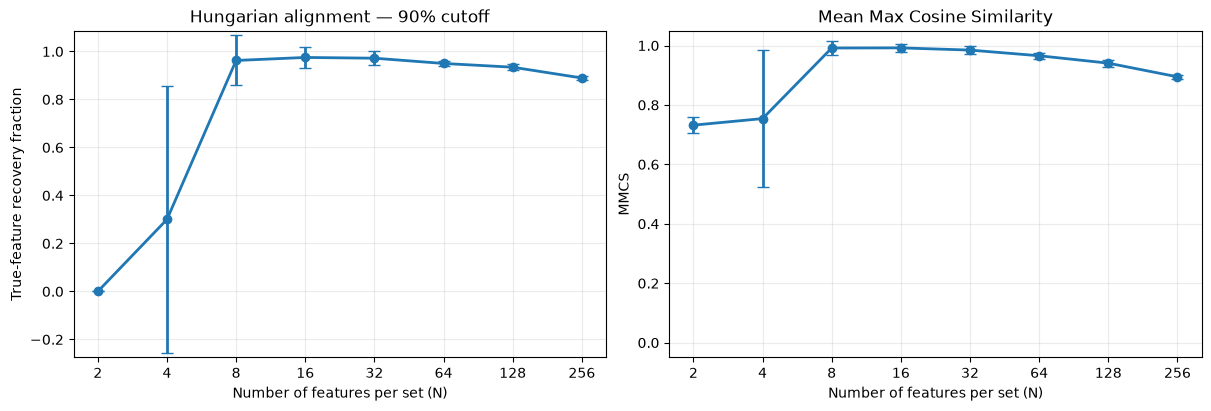

In [13]:
from math import sqrt

from scipy.stats import t as student_t


RUN_128M_FIVE_SEED_SWEEP = False
FIVE_SEED_TRAINING_SAMPLES = 128_000_000
FIVE_SAE_SEEDS = tuple(range(5))
FIVE_SEED_METRIC_SOURCES = {
    'hungarian_90': 'hungarian_recovery_fraction_90',
    'mmcs': 'mean_max_primitive_cosine',
}

five_seed_per_seed_path = (
    RESULTS_ROOT / 'n_primitive_recovery_128m_5_sae_seeds_per_seed.csv'
)
five_seed_aggregate_path = (
    RESULTS_ROOT / 'n_primitive_recovery_128m_5_sae_seeds_aggregate.csv'
)

five_seed_specs = [
    ExperimentSpec(
        study='n_sparsity_sweep_128m_5_sae_seeds',
        n_per_set=n_per_set,
        dictionary_seed=DICTIONARY_SEED,
        data_seed=DICTIONARY_SEED,
        sae_seed=sae_seed,
        training_samples=FIVE_SEED_TRAINING_SAMPLES,
    )
    for n_per_set in N_VALUES
    for sae_seed in FIVE_SAE_SEEDS
]


def run_five_seed_sweep(
    specs: Sequence[ExperimentSpec], summary_path: Path
) -> pd.DataFrame:
    columns = [
        'n_per_set',
        'sae_seed',
        'dictionary_seed',
        'data_seed',
        'training_samples',
        *FIVE_SEED_METRIC_SOURCES,
    ]
    completed = {}

    if summary_path.exists():
        saved = pd.read_csv(summary_path)
        missing = set(columns).difference(saved.columns)
        if missing:
            raise ValueError(
                f'{summary_path} is missing columns: {sorted(missing)}'
            )
        for row in saved[columns].to_dict(orient='records'):
            key = (int(row['n_per_set']), int(row['sae_seed']))
            completed[key] = row

    expected_keys = [(spec.n_per_set, spec.sae_seed) for spec in specs]
    for index, spec in enumerate(specs, start=1):
        key = (spec.n_per_set, spec.sae_seed)
        if key in completed:
            print(
                f'[{index}/{len(specs)}] Reused CSV row: '
                f'N={spec.n_per_set}, SAE seed={spec.sae_seed}'
            )
            continue

        print(
            f'[{index}/{len(specs)}] N={spec.n_per_set}, '
            f'SAE seed={spec.sae_seed}'
        )
        sae = train_or_load_sae(spec)
        recovery = primitive_recovery_metrics(sae, build_dictionary(spec))
        completed[key] = {
            'n_per_set': spec.n_per_set,
            'sae_seed': spec.sae_seed,
            'dictionary_seed': spec.dictionary_seed,
            'data_seed': spec.data_seed,
            'training_samples': spec.training_samples,
            **{
                output_name: recovery[source_name]
                for output_name, source_name in FIVE_SEED_METRIC_SOURCES.items()
            },
        }

        progress = pd.DataFrame(
            [completed[item] for item in expected_keys if item in completed]
        )[columns]
        progress.sort_values(['n_per_set', 'sae_seed']).to_csv(
            summary_path, index=False
        )

        del sae
        if DEVICE.type == 'mps':
            torch.mps.empty_cache()
        elif DEVICE.type == 'cuda':
            torch.cuda.empty_cache()

    missing_runs = [key for key in expected_keys if key not in completed]
    if missing_runs:
        raise RuntimeError(f'Missing completed runs: {missing_runs}')

    return (
        pd.DataFrame([completed[key] for key in expected_keys])[columns]
        .sort_values(['n_per_set', 'sae_seed'])
        .reset_index(drop=True)
    )


def aggregate_five_seed_recovery(frame: pd.DataFrame) -> pd.DataFrame:
    records = []
    expected_seeds = set(FIVE_SAE_SEEDS)

    for n_per_set, group in frame.groupby('n_per_set', sort=True):
        observed_seeds = set(group['sae_seed'].astype(int))
        if observed_seeds != expected_seeds:
            raise ValueError(
                f'N={int(n_per_set)} has SAE seeds {sorted(observed_seeds)}; '
                f'expected {sorted(expected_seeds)}.'
            )

        record = {
            'n_per_set': int(n_per_set),
            'n_sae_seeds': len(group),
        }
        for metric in FIVE_SEED_METRIC_SOURCES:
            values = group[metric].astype(float)
            mean = float(values.mean())
            standard_error = float(values.std(ddof=1) / sqrt(len(values)))
            half_width = float(
                student_t.ppf(0.975, df=len(values) - 1) * standard_error
            )
            record[f'{metric}_mean'] = mean
            record[f'{metric}_ci95_lower'] = mean - half_width
            record[f'{metric}_ci95_upper'] = mean + half_width
        records.append(record)

    return pd.DataFrame(records)


if RUN_128M_FIVE_SEED_SWEEP:
    five_seed_results = run_five_seed_sweep(
        five_seed_specs, five_seed_per_seed_path
    )
elif five_seed_per_seed_path.exists():
    five_seed_results = pd.read_csv(five_seed_per_seed_path)
else:
    raise FileNotFoundError(
        f'No saved five-seed results at {five_seed_per_seed_path}. '
        'Set RUN_128M_FIVE_SEED_SWEEP=True to train them.'
    )

five_seed_aggregate = aggregate_five_seed_recovery(five_seed_results)
five_seed_aggregate.to_csv(five_seed_aggregate_path, index=False)
display(five_seed_aggregate.style.format(precision=4))
print('Saved', five_seed_per_seed_path)
print('Saved', five_seed_aggregate_path)


FIVE_SEED_PLOT_SPECS = [
    (
        'hungarian_90',
        'Hungarian alignment — 90% cutoff',
        'True-feature recovery fraction',
        'hungarian_alignment_90_by_n_128m_5_sae_seeds.png',
    ),
    (
        'mmcs',
        'Mean Max Cosine Similarity',
        'MMCS',
        'mmcs_by_n_128m_5_sae_seeds.png',
    ),
]


def plot_five_seed_mean_with_ci(ax, frame, metric, title, ylabel):
    ordered = frame.sort_values('n_per_set')
    means = ordered[f'{metric}_mean']
    lower_errors = means - ordered[f'{metric}_ci95_lower']
    upper_errors = ordered[f'{metric}_ci95_upper'] - means
    ax.errorbar(
        ordered['n_per_set'],
        means,
        yerr=[lower_errors, upper_errors],
        marker='o',
        linewidth=2,
        capsize=4,
    )
    y_min = min(-0.05, float(ordered[f'{metric}_ci95_lower'].min()) - 0.02)
    y_max = max(1.05, float(ordered[f'{metric}_ci95_upper'].max()) + 0.02)
    ax.set(
        title=title,
        xlabel='Number of features per set (N)',
        ylabel=ylabel,
        ylim=(y_min, y_max),
    )
    ax.set_xscale('log', base=2)
    ax.set_xticks(ordered['n_per_set'])
    ax.set_xticklabels([str(int(n)) for n in ordered['n_per_set']])
    ax.get_xaxis().set_minor_formatter(plt.NullFormatter())
    ax.grid(alpha=0.25)


figure, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
for axis, (metric, title, ylabel, filename) in zip(
    axes, FIVE_SEED_PLOT_SPECS, strict=True
):
    plot_five_seed_mean_with_ci(
        axis, five_seed_aggregate, metric, title, ylabel
    )

    individual_figure, individual_axis = plt.subplots(figsize=(6, 4))
    plot_five_seed_mean_with_ci(
        individual_axis, five_seed_aggregate, metric, title, ylabel
    )
    individual_figure.tight_layout()
    output_path = RESULTS_ROOT / filename
    individual_figure.savefig(output_path, dpi=200, bbox_inches='tight')
    plt.close(individual_figure)
    print('Saved', output_path)

combined_plot_path = (
    RESULTS_ROOT / 'true_feature_recovery_by_n_128m_5_sae_seeds.png'
)
figure.savefig(combined_plot_path, dpi=200, bbox_inches='tight')
print('Saved', combined_plot_path)
plt.show()

## Interpretation

The original 250M sweep produces one SAE per `N`; the 128M robustness sweep
produces five SAEs per `N`.

- Higher Hungarian recovery means more true primitives have distinct learned
  decoder counterparts under a global one-to-one assignment.
- The 0.70 cutoff is permissive; the 0.80 and 0.90 cutoffs are stronger evidence
  of close primitive alignment.
- Higher MMCS means that, on average, each true
  primitive has a nearby learned decoder, without enforcing uniqueness.

A consistent upward trend with `N`, especially at Hungarian 0.90,
supports the claim that increased factorial sparsity encourages primitive
recovery.

The five-seed 128M means and confidence intervals show whether that trend is
stable to SAE initialization and training randomness. Per-seed results,
aggregate results, and figures are saved beneath
`artifacts/03_sparse_factorial_antipodal/results/`.